### Inicialmente minha ideia é criar visualizações com cores fixas ocupando o quadro inteiro.

Bibliotecas

In [2]:
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import ast
import os

In [ ]:
''' 

Vou tentar fazer alguma forma de seleção aqui

Minha ideia é fazer uma função que retorna uma função de detecção

Em geral o legal seria fazer alguma região que queremos que as imagens selecionada estejam, farei então a mais facil, um retangulo no espaço RGB
'''



def str_to_list(string_lista):
    """
    Transforma uma string contendo 'np.float64(valor)' em uma lista Python nativa.
    """

    string_limpa = re.sub(r'np\.float64\((.*?)\)', r'\1', string_lista)
    
    lista_real = ast.literal_eval(string_limpa)
    
    return lista_real
        


#A função que dada duas tuplas com inicios e fins retorna uma função que verifica se uma cordenada representada por uma tupla tripla está dentro das limitações que forão dadas
def detection_func(ini:tuple,fim:tuple):
    rzim,gzim,bzim = ini
    rzao,gzao,bzao = fim

    def func(cor:list):
        if cor in {'Local indefinido','Imagem nao existente'}:
            return False
        
        if type(cor) != list:
            cor = str_to_list(cor)[0]

        R = np.float64(cor[0])*255
        G = np.float64(cor[1])*255
        B= np.float64(cor[2])*255

        if (rzim < R and rzao> R)  and (gzim < G and gzao > G) and (bzim < B and bzao > B):
            return True
        else:
            return False
        
    return func

#função auxiliar para tentar verificar as imagens que estão dentro desse retangulo rgb
def color_show(ini:tuple,fim:tuple):
    ''' 
    É necessário ter o matplotlib.pyplot
    
    '''
    rzim,gzim,bzim = ini
    rzao,gzao,bzao = fim

    fig = plt.figure()
    ax = fig.add_subplot(111)

    R,G,B = [],[],[]

    rin = rzim
    gin = gzim
    bin = bzim

    for i in range(10):
        R.append([rzim,gin,bin])
        G.append([rin,gzim,bin])
        B.append([rin,gin,bzim])

        
        
        rzim += (rzao-rzim)/10
        gzim += (gzao-gzim)/10
        bzim += (bzao-bzim)/10


    R = np.array(R)
    G = np.array(G)
    B = np.array(B)


    quadrado = [R/255,G/255,B/255]


    plt.imshow(quadrado)
    plt.axis('off')



In [ ]:
#lendo o csv do arquivo
tabela = pd.read_csv('/home/lucca/Documents/Atividades escolares/impatech/Projeto portinari/Projeto-Portinari/Data/Obras_Cores.csv')

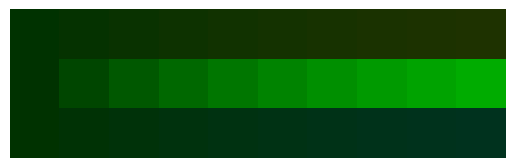

In [ ]:
#função para verificar o retangulo escolhido
color_show((0,50,0),(50,250,50))

In [ ]:
#aqui vou selecionar com o pandas as imagens e montar a visualização com as imagens selecionadas

#cria a funcao de deteccao para melhor selecao do pandas
func = detection_func((100,0,0),(250,70,70))
#cria a mascara para o pandas
mascara = [func(cor) for cor in tabela['cor']]
#dataframe já filtrado com as imagen com cores dentro da tabela
util = tabela[mascara]

#outro filtro para selecionar apenas imagens com uma proporcao x da cor especificada 
proporcao = 0.1
outra_mascara = [float(quanto) > proporcao for quanto in util['cor_proporcao']]
#faz a segunda filtragem no dataframe
util2 = util[outra_mascara]

#caminho onde estão as imagens
caminho_img = '/home/lucca/Documents/Atividades escolares/impatech/Projeto portinari/Projeto-Portinari/Data/imagens'


#criando o quadro em branco 
img = Image.new('RGB',(3000,2000),color = (255,255,255))


a,b = 0,0
#colando as imagens selecionadas no quadro branco 
for caminho in util2['imagemLocal']:

    imge = Image.open(os.path.join(caminho_img,caminho))
    imge = imge.resize((300,200), resample=Image.Resampling.BICUBIC)

    img.paste(imge,(a,b))

    a += 300
    a = a%3000
    if a == 0:
        b+=200

#mostrando a imagem
img.show()

In [7]:
func = detection_func((0,50,0),(100,250,100))
mascara = [func(cor) for cor in tabela['cor']]
util = tabela[mascara]

outra_mascara = [float(quanto) > 0.8 for quanto in util['cor_proporcao']]
util2 = util[outra_mascara]

caminho_img = '/home/lucca/Documents/Atividades escolares/impatech/Projeto portinari/Projeto-Portinari/Data/imagens'

print(util2['imagemLocal'])
#criando o quadro em branco 
img = Image.new('RGB',(3000,2000),color = (255,255,255))


a,b = 0,0

for caminho in util2['imagemLocal']:

    imge = Image.open(os.path.join(caminho_img,caminho))
    imge = imge.resize((300,200), resample=Image.Resampling.BICUBIC)

    img.paste(imge,(a,b))

    a += 300
    a = a%3000
    if a == 0:
        b+=200


img.show()

7                14741_Retrato_de_Maria_Torquato.jpeg
59                  14853_Paisagem_de_Petr_polis.jpeg
141                                16113_A_Barca.jpeg
200                       16271_Retrato_de_Maria.jpeg
210                       16289_Cabe_a_de_Mulher.jpeg
                            ...                      
1727    20092_Nossa_Senhora_da_Gl_ria_do_Outeiro.jpeg
1737                20108_Paisagem_de_Petr_polis.jpeg
1757                    20167_Menina_com_Cabrito.jpeg
1806                       20374_Negras_da_Bahia.jpeg
1816                            20427_O_Inc_ndio.jpeg
Name: imagemLocal, Length: 106, dtype: str
